<a href="https://colab.research.google.com/github/SeneshaMandakini/-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1

In [6]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving runway.png to runway.png


In [ ]:
# Load image
image = cv2.imread('runway.png',0)

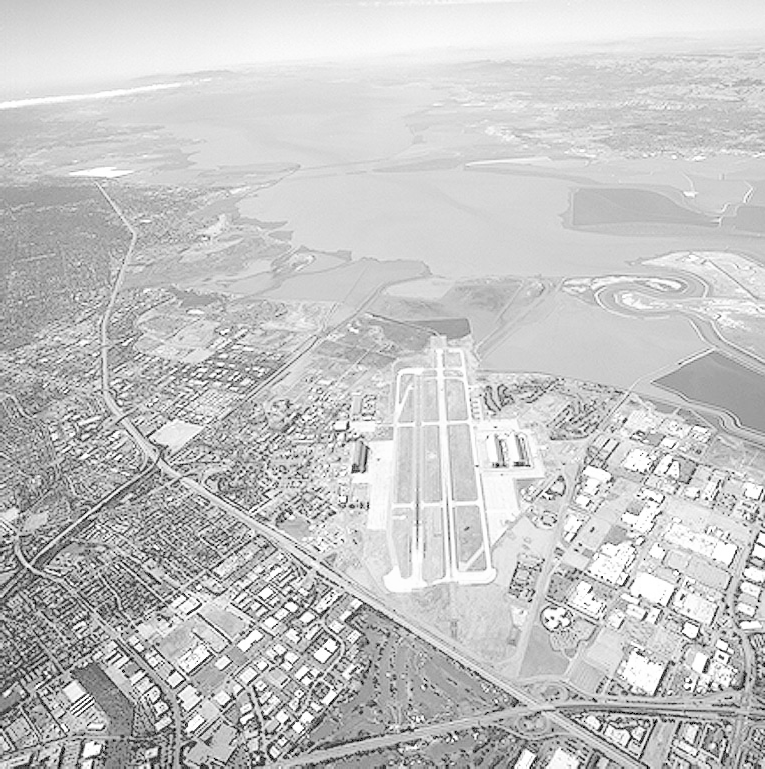

In [ ]:
cv2_imshow(image)

## a)

In [ ]:
gamma_1 = 2.0
invGamma_1 = 1.0 / gamma_1
table_1 = np.array([(i / 255.0) ** invGamma_1 * 255
                  for i in np.arange(0, 256)]).astype("uint8")

In [ ]:
# Apply gamma correction
new_image_1 = cv2.LUT(image, table_1)

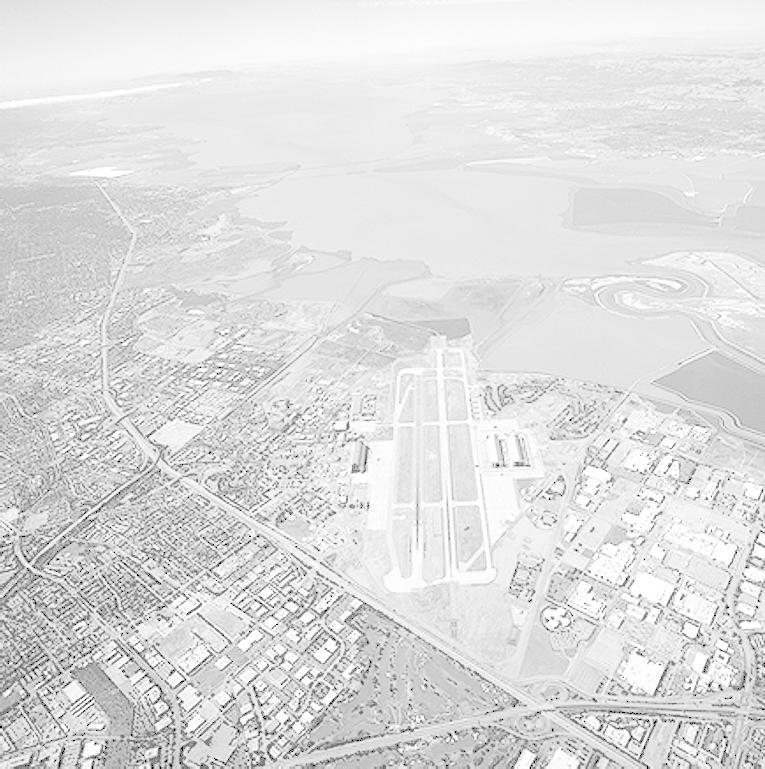

In [ ]:
cv2_imshow(new_image_1)

## b)

In [ ]:
gamma_2 = 0.5
invGamma_2 = 1.0 / gamma_2
table_2 = np.array([(i / 255.0) ** invGamma_2 * 255
                  for i in np.arange(0, 256)]).astype("uint8")

In [ ]:
# Apply gamma correction
new_image_2 = cv2.LUT(image, table_2)

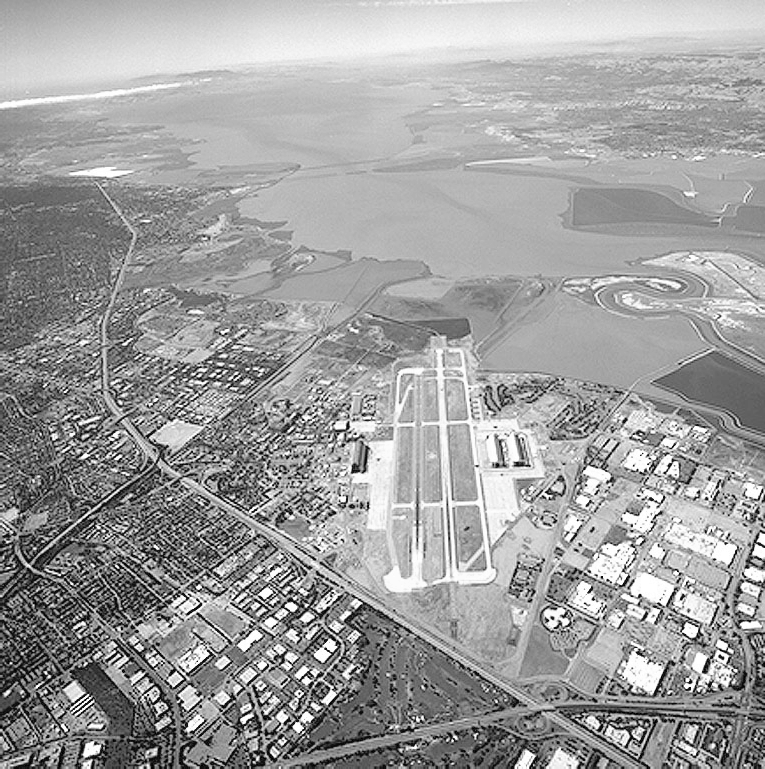

In [ ]:
cv2_imshow(new_image_2)

## c)

In [ ]:
stretched = ((image - 0.2) / (0.8 - 0.2)).astype('uint8')

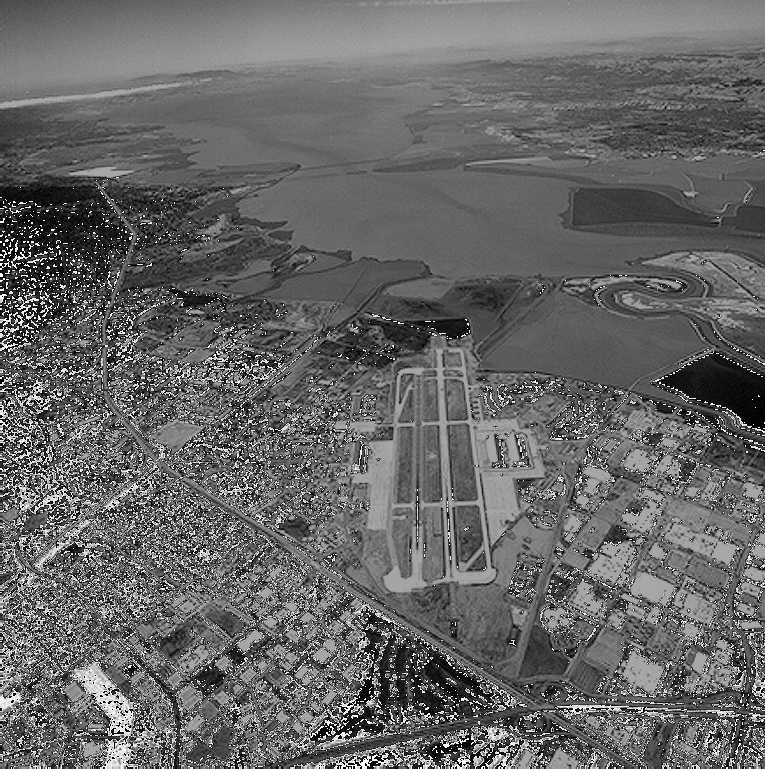

In [ ]:
cv2_imshow(stretched)

# Question 2

In [ ]:
uploaded_2 = files.upload()

Saving highlights_and_shadows.jpg to highlights_and_shadows.jpg


In [ ]:
image_2 = cv2.imread('highlights_and_shadows.jpg')

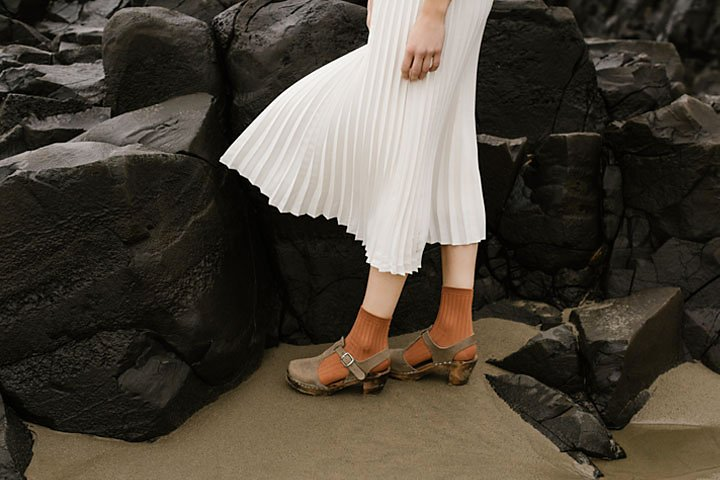

In [ ]:
cv2_imshow(image_2)

## a)

In [ ]:
lab = cv2.cvtColor(image_2, cv2.COLOR_BGR2LAB)

In [ ]:
l,a,b = cv2.split(lab)

In [ ]:
l_norm = l/255.0

In [ ]:
gamma = 0.5
l_gamma = np.power(l_norm, gamma)

In [ ]:
l_new = (l_gamma * 255).astype('uint8')


lab_new = cv2.merge((l_new, a, b))
result = cv2.cvtColor(lab_new, cv2.COLOR_LAB2BGR)

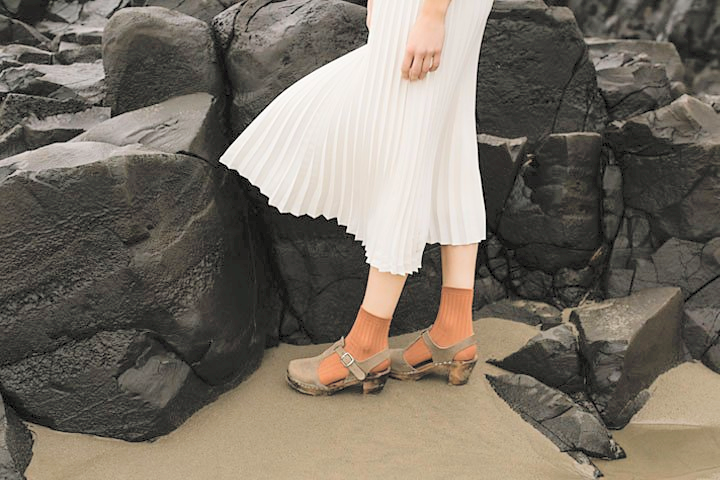

In [ ]:
cv2_imshow(result)

## b)

In [ ]:
import matplotlib.pyplot as plt

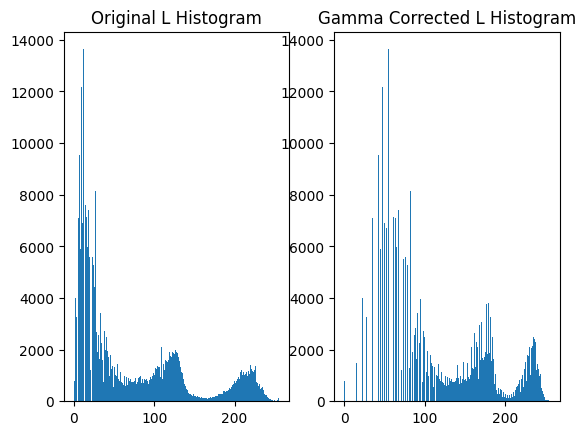

In [ ]:

plt.subplot(1, 2, 1)
plt.hist(l.ravel(), bins=256)
plt.title('Original L Histogram')


plt.subplot(1, 2, 2)
plt.hist(l_new.ravel(), bins=256)
plt.title('Gamma Corrected L Histogram')

plt.show()

# Question 3

In [ ]:
def hist_equalization(img):

    flat = img.flatten()

    hist = np.zeros(256)
    for pixel in flat:
        hist[pixel] += 1

    cdf = hist.cumsum()

    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype('uint8')

    equalized = cdf_normalized[flat]

    equalized_img = equalized.reshape(img.shape)

    return equalized_img

In [ ]:
eq_image = hist_equalization(image)

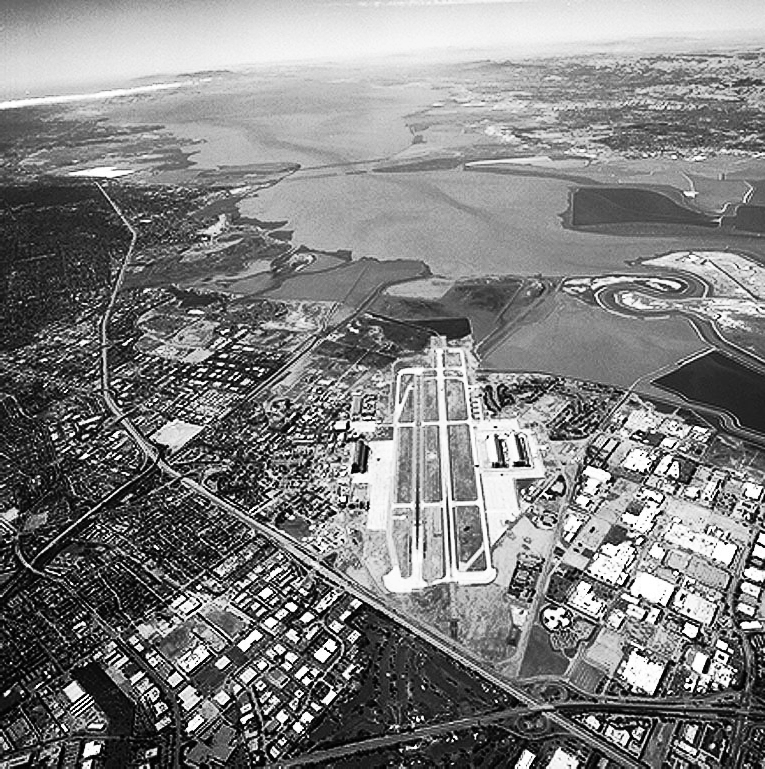

In [ ]:
cv2_imshow(eq_image)

# Question 4

In [ ]:
uploaded = files.upload()

Saving download.jpg to download.jpg


In [ ]:
images_3 = cv2.imread('download.jpg')

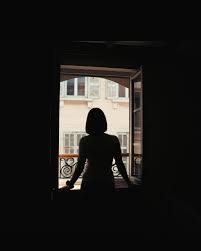

In [ ]:
cv2_imshow(images_3)

In [ ]:
gray_image = cv2.cvtColor(images_3, cv2.COLOR_BGR2GRAY)

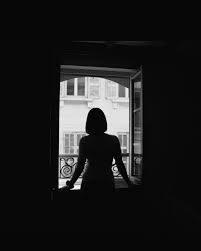

In [ ]:
cv2_imshow(gray_image)

## a)

In [ ]:
threshold_value, binary_mask = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print("Otsu Threshold Value:", threshold_value)

Otsu Threshold Value: 100.0


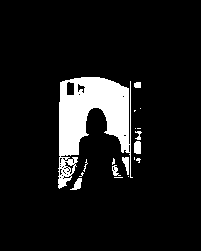

In [ ]:
cv2_imshow(binary_mask)

## b)

In [ ]:
equalized = cv2.equalizeHist(gray_image)

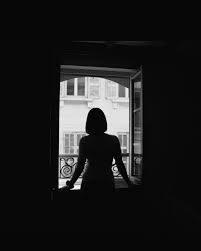

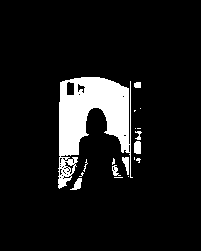

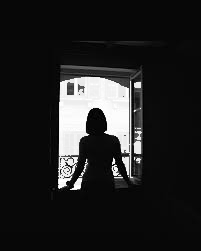

In [ ]:
result = gray_image.copy()
result[binary_mask == 255] = equalized[binary_mask == 255]

cv2_imshow(gray_image)
cv2_imshow(binary_mask)
cv2_imshow(result)



# Question 5

## a)

In [2]:
import numpy as np

def gaussian_kernel(size, sigma):
    ax = np.linspace(-(size // 2), size // 2, size)
    x, y = np.meshgrid(ax, ax)

    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))

    return kernel / np.sum(kernel)

kernel_5x5 = gaussian_kernel(5, 2)
print("5x5 Gaussian Kernel (sigma=2):\n", kernel_5x5)

5x5 Gaussian Kernel (sigma=2):
 [[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


## b)

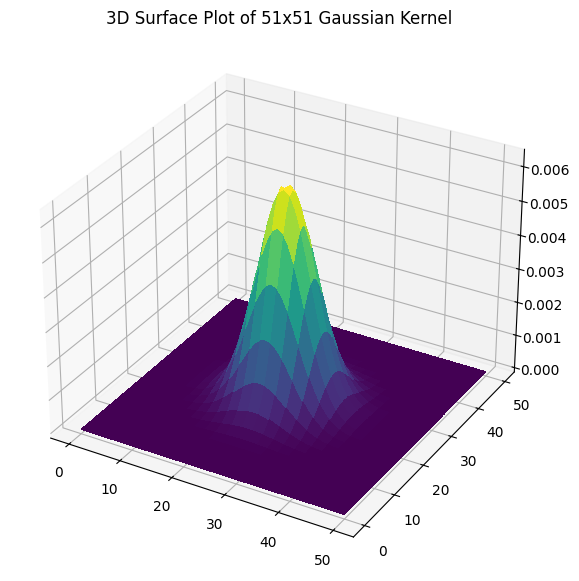

In [3]:
import matplotlib.pyplot as plt
from matplotlib import cm

# Generate 51x51 kernel
size = 51
sigma = 5
kernel_51 = gaussian_kernel(size, sigma)

# Setup 3D plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 7))
X, Y = np.meshgrid(np.arange(size), np.arange(size))

surf = ax.plot_surface(X, Y, kernel_51, cmap=cm.viridis, antialiased=False)
ax.set_title(f'3D Surface Plot of {size}x{size} Gaussian Kernel')
plt.show()

## c)

In [5]:
import cv2 as cv
from scipy.signal import convolve2d

In [7]:
uploaded = files.upload()

Saving einstein.png to einstein.png


In [8]:
images_5 = cv2.imread('einstein.png')

In [11]:
gray_images_5 = cv2.cvtColor(images_5, cv2.COLOR_BGR2GRAY)
manual_blurred = convolve2d(gray_images_5, kernel_5x5, mode='same', boundary='fill', fillvalue=0)

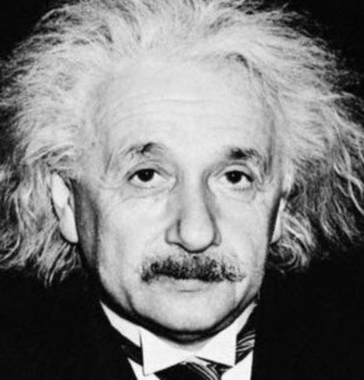

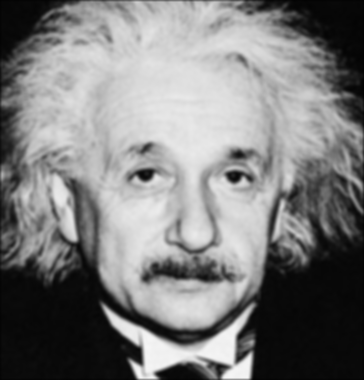

In [13]:
cv2_imshow(gray_images_5)
cv2_imshow(manual_blurred)

## d)

In [14]:
opencv_blurred = cv.GaussianBlur(images_5, (5, 5), 2)

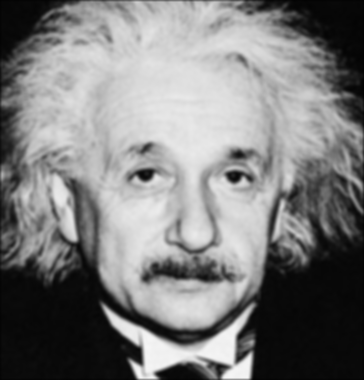

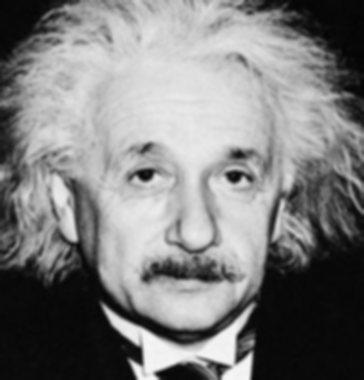

In [15]:
cv2_imshow(manual_blurred)
cv2_imshow(opencv_blurred)